In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [95]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_18696\795541288.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [96]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)


Unique values in 'potentially_hazardous': [False True 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False True 'FALSE' 'TRUE' 'Unknown']
potentially_hazardous    object
near_earth_object        object
dtype: object


In [97]:
# Convert all values to uppercase strings for consistency
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Define mappings
hazardous_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "N": 0  # 'N' treated as non-hazardous
}

neo_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "UNKNOWN": 0  # assuming 'Unknown' means not confirmed as NEO
}

# Apply mappings and convert to int
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
df["near_earth_object"] = df["near_earth_object"].map(neo_mapping).astype(int)


In [98]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())


Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [99]:
df.head()

,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,0,0,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,0,0,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,0,0,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,0,0,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,0,0,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [85]:
# Keep only the relevant columns for Naïve Bayes modeling
columns_to_keep = [
    # Target
    'potentially_hazardous',

    # Multinomial NB (binned later)
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'orbital_inclination_deg',
    'near_earth_object',

    # Gaussian NB (continuous)
    'aphelion_distance_au',

    # Categorical NB (to be binned into categories)
    'earth_moid_au',
    'orbit_fit_rms',
    'asteroid_class'
]

# Create a new DataFrame for NB modeling
df = df[columns_to_keep].copy()


In [86]:
# Multinomial NB features (bin later)
mnb_features = [
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'orbital_inclination_deg',
    'near_earth_object'
]

# Gaussian NB features (continuous)
gnb_features = [
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'aphelion_distance_au',
    'orbital_inclination_deg'
]

# Categorical NB features (categorical, handled separately)
cnb_features = [
    'earth_moid_au',
    'orbit_fit_rms',
    'asteroid_class'
]

# Prepare cleaned versions
df_mnb = df[mnb_features + ['potentially_hazardous']].copy()
df_gnb = df[gnb_features + ['potentially_hazardous']].copy()
df_cnb = df[cnb_features + ['potentially_hazardous']].copy()


In [87]:
df.dtypes

potentially_hazardous        int32
absolute_magnitude         float64
diameter_km                float64
semi_major_axis_au         float64
orbital_inclination_deg    float64
near_earth_object            int32
aphelion_distance_au       float64
earth_moid_au              float64
orbit_fit_rms              float64
asteroid_class              object
dtype: object

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the DataFrame (assuming it's already available in variable `df`)
# Let's first inspect class distribution
class_counts = df['potentially_hazardous'].value_counts()
class_counts

potentially_hazardous
0    956458
1      2066
Name: count, dtype: int64

In [90]:
from sklearn.model_selection import train_test_split

def balance_and_split(df, features):
    df_hazardous = df[df['potentially_hazardous'] == 1]
    df_non_hazardous = df[df['potentially_hazardous'] == 0].sample(n=len(df_hazardous), random_state=42)

    df_balanced = pd.concat([df_hazardous, df_non_hazardous], axis=0).sample(frac=1, random_state=42)

    X = df_balanced[features]
    y = df_balanced['potentially_hazardous']

    return train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Multinomial NB
X_train_mnb, X_test_mnb, y_train_mnb, y_test_mnb = balance_and_split(df_mnb, mnb_features)

# Gaussian NB
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = balance_and_split(df_gnb, gnb_features)

# Categorical NB
X_train_cnb, X_test_cnb, y_train_cnb, y_test_cnb = balance_and_split(df_cnb, cnb_features)


🔷 Multinomial NB Accuracy: 0.9919354838709677


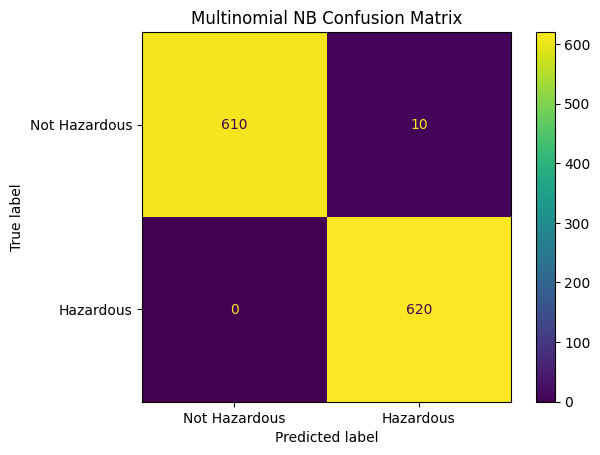

In [91]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### ---------------- MULTINOMIAL NB ---------------- ###
# Bin numeric features for Multinomial NB
def bin_features_multinomial(df):
    df_binned = df.copy()
    for col in df_binned.columns:
        df_binned[col] = pd.cut(df_binned[col], bins=5, labels=False)
    return df_binned

X_train_mnb_binned = bin_features_multinomial(X_train_mnb)
X_test_mnb_binned = bin_features_multinomial(X_test_mnb)

# Train and evaluate
mnb = MultinomialNB()
mnb.fit(X_train_mnb_binned, y_train_mnb)
y_pred_mnb = mnb.predict(X_test_mnb_binned)

print("🔷 Multinomial NB Accuracy:", accuracy_score(y_test_mnb, y_pred_mnb))
ConfusionMatrixDisplay.from_predictions(y_test_mnb, y_pred_mnb, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Multinomial NB Confusion Matrix")
plt.show()

🟢 Gaussian NB Accuracy: 0.7153225806451613


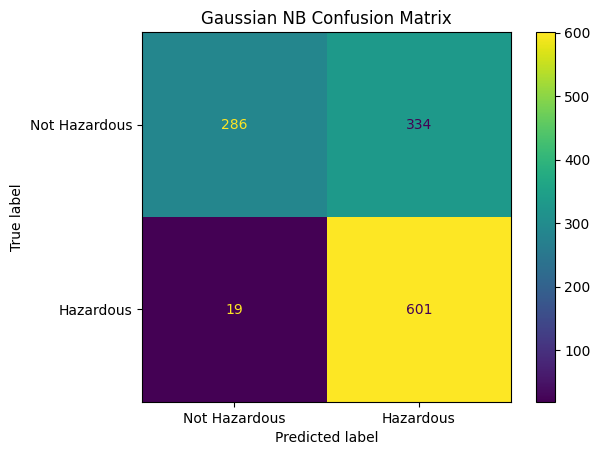

In [92]:
### ---------------- GAUSSIAN NB ---------------- ###
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)
y_pred_gnb = gnb.predict(X_test_gnb)

print("🟢 Gaussian NB Accuracy:", accuracy_score(y_test_gnb, y_pred_gnb))
ConfusionMatrixDisplay.from_predictions(y_test_gnb, y_pred_gnb, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Gaussian NB Confusion Matrix")
plt.show()

🟣 Categorical NB Accuracy: 0.9411290322580645


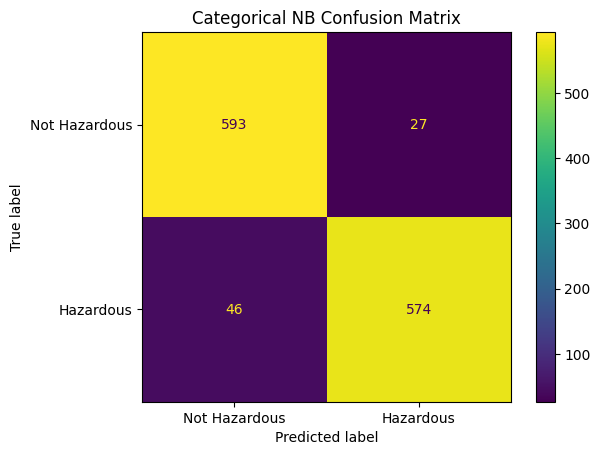

In [93]:
### ---------------- CATEGORICAL NB ---------------- ###
# Convert categorical features to integer labels
X_train_cnb_encoded = X_train_cnb.apply(lambda col: pd.factorize(col)[0])
X_test_cnb_encoded = X_test_cnb.apply(lambda col: pd.factorize(col)[0])

cnb = CategoricalNB()
cnb.fit(X_train_cnb_encoded, y_train_cnb)
y_pred_cnb = cnb.predict(X_test_cnb_encoded)

print("🟣 Categorical NB Accuracy:", accuracy_score(y_test_cnb, y_pred_cnb))
ConfusionMatrixDisplay.from_predictions(y_test_cnb, y_pred_cnb, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Categorical NB Confusion Matrix")
plt.show()

In [100]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Select new expanded feature set
expanded_features = [
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'aphelion_distance_au',
    'perihelion_distance_au',
    'orbital_inclination_deg',
    'mean_motion_deg_day',
    'earth_moid_au',
    'orbital_period_days',
    'uncertainty_eccentricity',
    'uncertainty_mean_anomaly',
    'near_earth_object'
]

X = df[expanded_features].copy()
y = df['potentially_hazardous']

# Fill or drop missing values if needed
X = X.fillna(0)

# SMOTE Oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train/test split on SMOTE output
X_train_smt, X_test_smt, y_train_smt, y_test_smt = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)


In [104]:
#print the class distribution after SMOTE
print("Class distribution after SMOTE:" , y_resampled.value_counts())    

Class distribution after SMOTE: potentially_hazardous
0    956458
1    956458
Name: count, dtype: int64


🔷 Multinomial NB (with SMOTE & Expanded Features) Accuracy: 0.9886856893922893


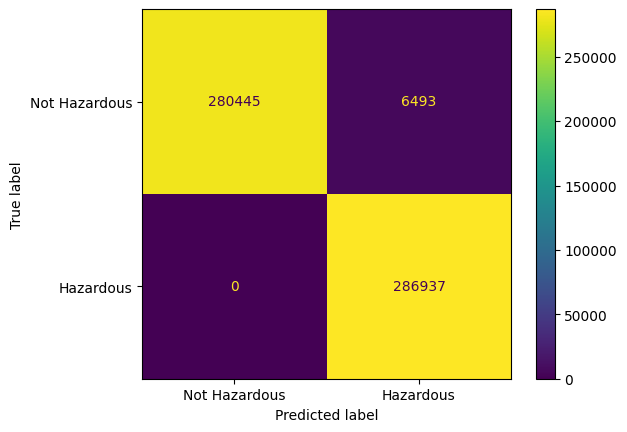

In [101]:
# Binning all features into 5 discrete bins
X_train_mnb_smt = X_train_smt.copy()
X_test_mnb_smt = X_test_smt.copy()

for col in X_train_mnb_smt.columns:
    X_train_mnb_smt[col] = pd.cut(X_train_mnb_smt[col], bins=5, labels=False)
    X_test_mnb_smt[col] = pd.cut(X_test_smt[col], bins=5, labels=False)

# Train and evaluate Multinomial NB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

mnb_smt = MultinomialNB()
mnb_smt.fit(X_train_mnb_smt, y_train_smt)
y_pred_mnb_smt = mnb_smt.predict(X_test_mnb_smt)

print("🔷 Multinomial NB (with SMOTE & Expanded Features) Accuracy:", accuracy_score(y_test_smt, y_pred_mnb_smt))
ConfusionMatrixDisplay.from_predictions(y_test_smt, y_pred_mnb_smt, display_labels=["Not Hazardous", "Hazardous"])


🟢 Gaussian NB (SMOTE + Expanded Features) Accuracy: 0.5109143977346984


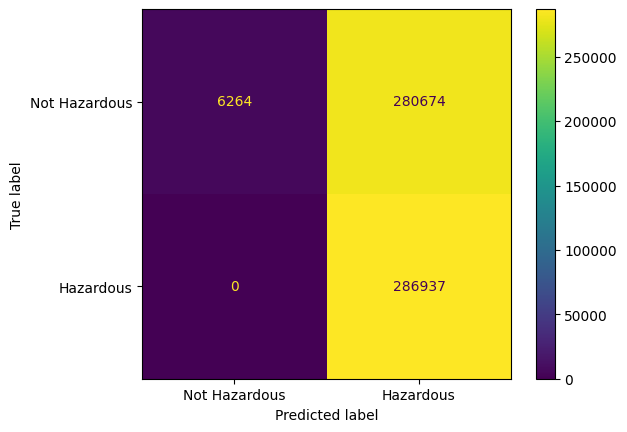

In [105]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Use original (non-binned) SMOTE-resampled data
gnb = GaussianNB()
gnb.fit(X_train_smt, y_train_smt)
y_pred_gnb_smt = gnb.predict(X_test_smt)

print("🟢 Gaussian NB (SMOTE + Expanded Features) Accuracy:", accuracy_score(y_test_smt, y_pred_gnb_smt))
ConfusionMatrixDisplay.from_predictions(y_test_smt, y_pred_gnb_smt, display_labels=["Not Hazardous", "Hazardous"])


🟣 Categorical NB (SMOTE + Expanded Features) Accuracy: 0.9547898061424527


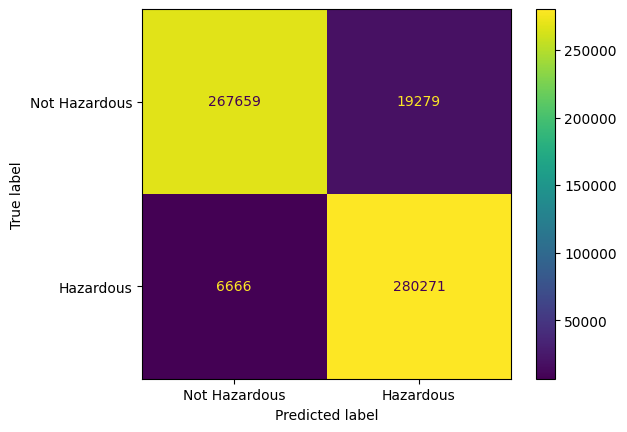

In [106]:
from sklearn.naive_bayes import CategoricalNB

# Discretize all numeric features into bins (labels become categories)
X_train_cnb_smt = X_train_smt.copy()
X_test_cnb_smt = X_test_smt.copy()

# Bin into 5 quantiles (or equal-width if you prefer)
for col in X_train_cnb_smt.columns:
    X_train_cnb_smt[col] = pd.qcut(X_train_cnb_smt[col], q=5, duplicates='drop', labels=False)
    X_test_cnb_smt[col] = pd.qcut(X_test_cnb_smt[col], q=5, duplicates='drop', labels=False)

# Fit Categorical NB
cnb = CategoricalNB()
cnb.fit(X_train_cnb_smt, y_train_smt)
y_pred_cnb_smt = cnb.predict(X_test_cnb_smt)

print("🟣 Categorical NB (SMOTE + Expanded Features) Accuracy:", accuracy_score(y_test_smt, y_pred_cnb_smt))
ConfusionMatrixDisplay.from_predictions(y_test_smt, y_pred_cnb_smt, display_labels=["Not Hazardous", "Hazardous"])
